# Exploratory Data Analysis (EDA)

The goal of this EDA is to understand how churned and retained customers differ
across demographics, services, contract characteristics, and billing behavior.

EDA is used to:
- Build business intuition around churn
- Identify potentially useful predictive signals
- Detect data quality issues early

This analysis is descriptive and avoids any feature engineering or modeling.


In [1]:
import pandas as pd

# Load dataset
df = pd.read_csv("C:/Users/suraj/Documents/3. IT/3.6 Projects/3.6.2 Customer Churn/data/raw/customer_churn.csv")

# Basic sanity checks
print("Shape:", df.shape)
df.head()


Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
# Check data types and non-null counts
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [3]:
# Check for empty strings across all columns
(df == "").sum().sort_values(ascending=False)


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [4]:
# Try converting TotalCharges to numeric to expose hidden issues
total_charges_numeric = pd.to_numeric(df["TotalCharges"], errors="coerce")

# How many values failed conversion?
total_charges_numeric.isna().sum()


np.int64(11)

In [5]:
# Churn distribution (counts)
df["Churn"].value_counts()


Churn
No     5174
Yes    1869
Name: count, dtype: int64

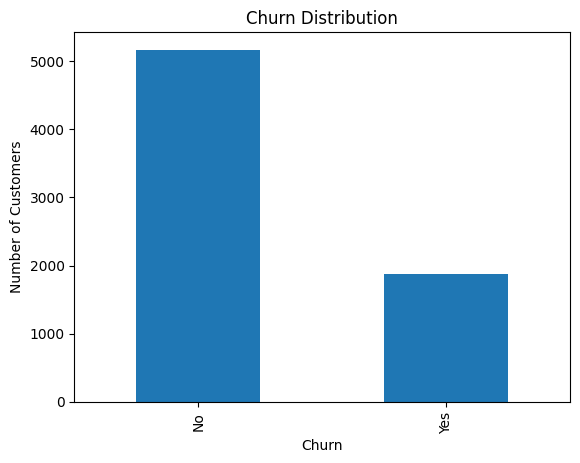

In [6]:
import matplotlib.pyplot as plt

# Bar plot of churn distribution
df["Churn"].value_counts().plot(kind="bar")
plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()


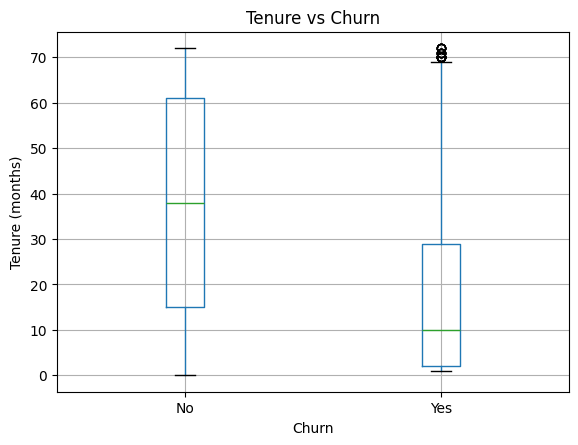

In [7]:
# Compare tenure distribution by churn
df.boxplot(column="tenure", by="Churn")
plt.title("Tenure vs Churn")
plt.suptitle("")  # remove default subtitle
plt.xlabel("Churn")
plt.ylabel("Tenure (months)")
plt.show()


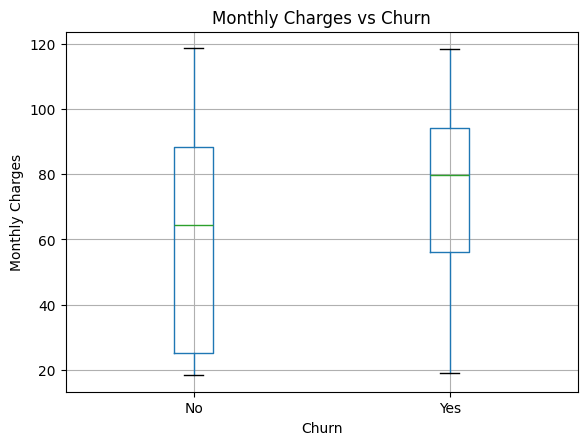

In [8]:
# Monthly charges vs churn
df.boxplot(column="MonthlyCharges", by="Churn")
plt.title("Monthly Charges vs Churn")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.show()


In [9]:
# Create tenure buckets
df["tenure_group"] = pd.cut(
    df["tenure"],
    bins=[0, 12, 24, 48, 72],
    labels=["0-1yr", "1-2yr", "2-4yr", "4-6yr"],
    include_lowest=True
)

# Churn rate by tenure group
churn_by_tenure = (
    df.groupby("tenure_group")["Churn"]
      .value_counts(normalize=True)
      .unstack()
)

churn_by_tenure


Churn,No,Yes
tenure_group,,
0-1yr,0.525618,0.474382
1-2yr,0.712891,0.287109
2-4yr,0.796110,0.203890
4-6yr,0.904868,0.095132


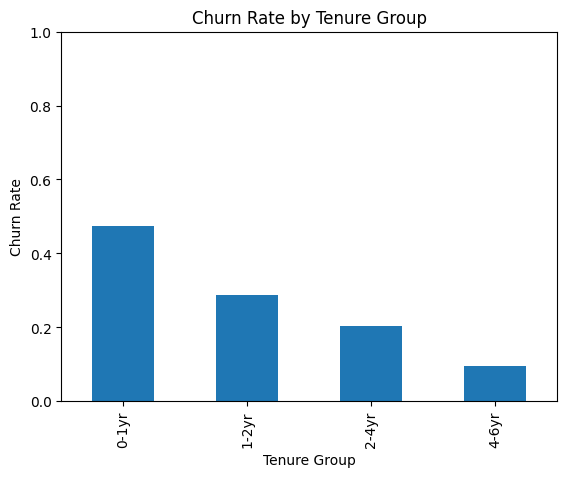

In [10]:
# Plot churn rate by tenure group
churn_by_tenure["Yes"].plot(kind="bar")
plt.title("Churn Rate by Tenure Group")
plt.ylabel("Churn Rate")
plt.xlabel("Tenure Group")
plt.ylim(0, 1)
plt.show()


In [11]:
# Churn rate by contract type
churn_by_contract = (
    df.groupby("Contract")["Churn"]
      .value_counts(normalize=True)
      .unstack()
)

churn_by_contract


Churn,No,Yes
Contract,,
Month-to-month,0.572903,0.427097
One year,0.887305,0.112695
Two year,0.971681,0.028319


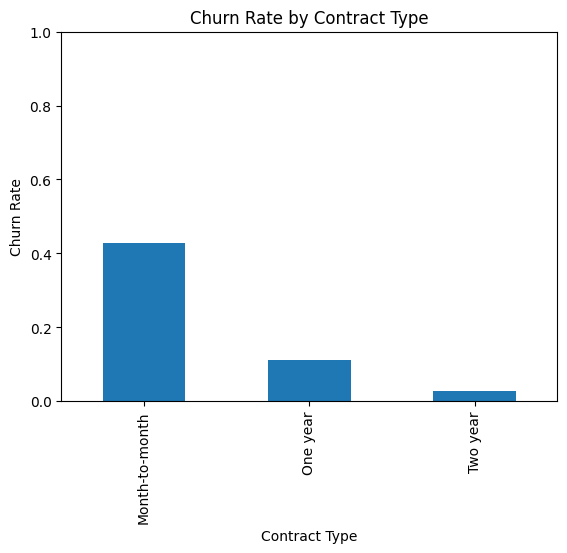

In [13]:
# Plot churn rate by contract type
churn_by_contract["Yes"].plot(kind="bar")
plt.title("Churn Rate by Contract Type")
plt.ylabel("Churn Rate")
plt.xlabel("Contract Type")
plt.ylim(0, 1)
plt.show()


In [14]:
# Churn rate by Internet service type
churn_by_internet = (
    df.groupby("InternetService")["Churn"]
      .value_counts(normalize=True)
      .unstack()
)

churn_by_internet


Churn,No,Yes
InternetService,,
DSL,0.810409,0.189591
Fiber optic,0.581072,0.418928
No,0.925950,0.074050


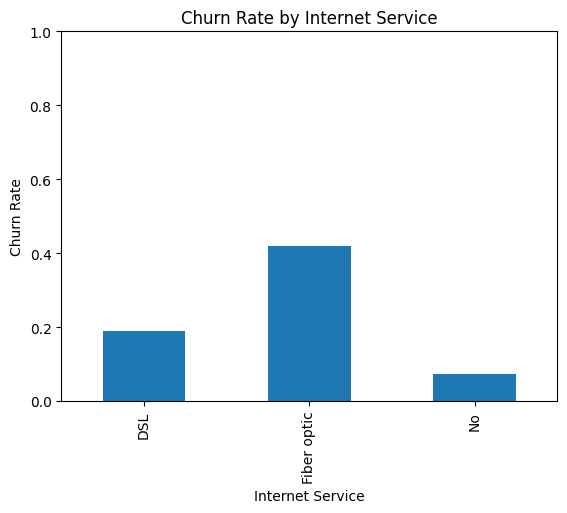

In [15]:
# Plot churn rate by Internet service type
churn_by_internet["Yes"].plot(kind="bar")
plt.title("Churn Rate by Internet Service")
plt.ylabel("Churn Rate")
plt.xlabel("Internet Service")
plt.ylim(0, 1)
plt.show()


In [16]:
# Churn rate by TechSupport
churn_by_techsupport = (
    df.groupby("TechSupport")["Churn"]
      .value_counts(normalize=True)
      .unstack()
)

churn_by_techsupport


Churn,No,Yes
TechSupport,,
No,0.583645,0.416355
No internet service,0.925950,0.074050
Yes,0.848337,0.151663


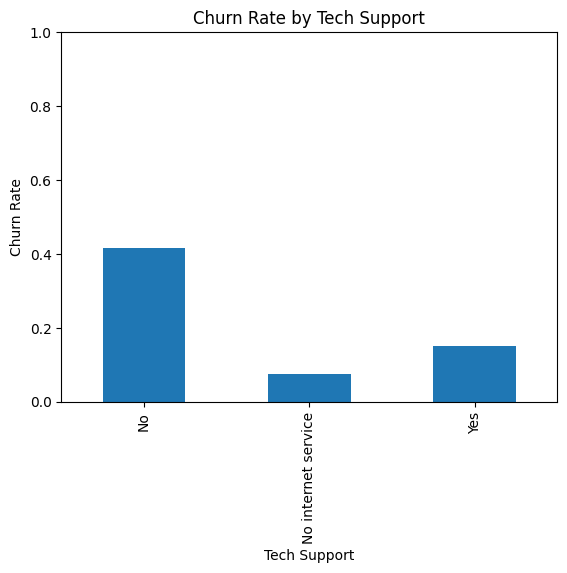

In [17]:
# Plot churn rate by TechSupport
churn_by_techsupport["Yes"].plot(kind="bar")
plt.title("Churn Rate by Tech Support")
plt.ylabel("Churn Rate")
plt.xlabel("Tech Support")
plt.ylim(0, 1)
plt.show()


## EDA Summary & Key Takeaways

Based on exploratory data analysis, customer churn is strongly influenced by a small set of core variables:

- **Tenure:** Churn decreases significantly as customer tenure increases. New customers (0–1 year) exhibit the highest churn risk.
- **Contract Type:** Month-to-month contracts show substantially higher churn compared to one-year and two-year contracts.
- **Internet Service:** Customers using fiber optic internet have higher churn rates than DSL or customers without internet service.
- **Tech Support:** Availability of technical support is strongly associated with lower churn.

These features emerge as the primary drivers of churn and will be emphasized during modeling.

Other demographic and service-related variables (e.g., gender, partner status, streaming services) show weaker individual relationships with churn and will be retained for modeling, allowing the algorithm to determine their contribution.
